# Feature selector -- version HORARIA

- Carga: `construir_dataset_horario()` + `dividir_train_val_test_horario()`.
- Spearman: `hora`/`dow`/`month`/`is_weekend` quedan protegidas (la relacion precio-hora
  es en U, no monotona, y Spearman la mataria).
- SFS: se ajusta sobre las ultimas 8760 horas de train por coste de computo.
- Huecos e indices: `freq='h'` en vez de `'D'`, y se quita la tz UTC antes de statsmodels.
- SARIMA/SARIMAX: `m=24` en vez de `m=7`, con busqueda de orden sobre ventana reciente.
- Baseline naive: `t-24` (misma hora de ayer) en vez de `t-1`.


In [1]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import sys
sys.path.append("C:/Users/Powan/Desktop/Maestria/TFM/edev_models/modelos")

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from datetime import date


# Load dataset

In [2]:
from construir_dataset_horario import construir_dataset_horario

# ---------------------------------------------------------------------------
# FRONTERAS DEL SPLIT -- fijadas por la instruccion del 27-ago-2026. NO TOCAR.
#   train:      hasta el 31-dic-2024 inclusive
#   validation: 2025 completo
#   test:       2026 -> SELLADO hasta el 31-ago-2026, una sola apertura
# Se definen AQUI y no se usa `dividir_train_val_test_horario`, que hereda
# TRAIN_END/VAL_END de construir_dataset_maestro (compartidas con el dataset diario):
# si alguien cambia alli las fechas, este notebook no se entera y entrenamos con 2026.
# ---------------------------------------------------------------------------
TRAIN_END_TFM = date(2024, 12, 31)
VAL_END_TFM = date(2025, 12, 31)
FECHA_APERTURA_TEST = date(2026, 8, 31)


def dividir_train_val_test_tfm(dataset, train_end=TRAIN_END_TFM, val_end=VAL_END_TFM):
    """Mismo criterio que `dividir_train_val_test_horario`: el split se decide por el
    dia D que hace la prediccion (fecha local Madrid de la fila, menos 1 dia), no por la
    hora objetivo -- asi un dia entero cae siempre entero en el mismo split, y las 00:00
    y 01:00 UTC del 1-ene no se van al split del año anterior por el desfase de tz.
    Lo unico que cambia son las fronteras.
    """
    dia_objetivo = pd.Series(
        dataset.index.tz_convert("Europe/Madrid").date,
        index=dataset.index,
    )
    return (
        dataset[dia_objetivo <= train_end],
        dataset[(dia_objetivo > train_end) & (dia_objetivo <= val_end)],
        dataset[dia_objetivo > val_end],
    )


dataset = construir_dataset_horario()
train_raw, val_raw, test_raw = dividir_train_val_test_tfm(dataset)

print(f"dataset: {dataset.shape[0]} filas (horas) x {dataset.shape[1]} columnas")
print(f"train: {len(train_raw)} horas  ({train_raw.index.min()} -> {train_raw.index.max()})")
print(f"val:   {len(val_raw)} horas  ({val_raw.index.min()} -> {val_raw.index.max()})")
print(f"test:  {len(test_raw)} horas  ({test_raw.index.min()} -> {test_raw.index.max()})  [SELLADO]")

C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_data

dataset: 58025 filas (horas) x 121 columnas
train: 43842 horas  (2020-01-01 00:00:00+00:00 -> 2024-12-31 22:00:00+00:00)
val:   8759 horas  (2024-12-31 23:00:00+00:00 -> 2025-12-31 22:00:00+00:00)
test:  5424 horas  (2025-12-31 23:00:00+00:00 -> 2026-08-14 22:00:00+00:00)  [SELLADO]


In [3]:
TARGET = "precio"  # unica columna de destino del dataset horario

def preparar_xy(df: pd.DataFrame, target: str = TARGET):
    """Separa el target del resto de features.

    En el dataset horario la fila YA ES la hora objetivo, asi que no hay columnas
    price_h00..price_h23 que descartar: solo hay que sacar `precio`.

    OJO: las columnas *_lag24h / *_lag168h (incluida precio_propio_lag24h) NO son fuga
    -- son datos que ya habian ocurrido cuando se cerro el mercado del dia anterior.
    Y `hora` ahora es una feature mas, no una columna distinta por hora.
    """
    if target not in df.columns:
        raise ValueError(f"{target!r} no esta en el dataset: {list(df.columns)[:10]}...")

    y = df[target].rename(target)
    X = df.drop(columns=[target])
    return X, y

# Solo train y validation. El test se prepara en la ultima seccion, el dia que se abra.
X_train, y_train = preparar_xy(train_raw)
X_val, y_val = preparar_xy(val_raw)

print(X_train.shape, X_val.shape)

(43842, 120) (8759, 120)


# Spearman feature selector

In [4]:
def select_features_spearman(
    X: pd.DataFrame,
    y: pd.Series,
    target_threshold: float = 0.10,
    collinearity_threshold: float = 0.90,
    p_value_max: float = 0.05,
    min_overlap: int = 30,
    siempre_incluir: tuple = ("hora", "dow", "month", "is_weekend"),
) -> dict:
    """
    Fit this on the TRAIN split only -- selection must not see val/test rows.

    Stage 1: keep features whose Spearman correlation with the target is
    both meaningful (|rho| >= target_threshold) and significant (p < p_value_max).
    Stage 2: among survivors, greedily drop redundant features -- for any pair
    with |pairwise rho| >= collinearity_threshold, keep the one more correlated
    with the target and drop the other.

    `siempre_incluir`: features protegidas, nunca se descartan. Imprescindible en el
    dataset horario -- la relacion precio/hora del dia es en U (caro de mañana y de
    noche, barato al mediodia), asi que NO es monotona y Spearman le da un rho casi
    cero. Sin esta proteccion el selector tiraria la feature mas importante del
    dataset horario.

    Returns:
      selected           -- final feature list, ordered by |rho| with target
      target_corr        -- rho with target for every numeric input feature
      dropped_low_corr    -- cut in stage 1 (weak or non-significant)
      dropped_collinear   -- cut in stage 2, redundant with a stronger feature
    """
    X_num = X.select_dtypes(include=[np.number])
    protegidas = [c for c in siempre_incluir if c in X_num.columns]

    rho, pval = {}, {}
    for col in X_num.columns:
        mask = X_num[col].notna() & y.notna()
        if mask.sum() < min_overlap:
            rho[col], pval[col] = np.nan, np.nan
            continue
        r, p = spearmanr(X_num.loc[mask, col], y[mask])
        rho[col], pval[col] = r, p

    target_corr = pd.Series(rho)
    pvals = pd.Series(pval)

    survivors = [
        c for c in X_num.columns
        if c in protegidas
        or (pd.notna(target_corr[c])
            and abs(target_corr[c]) >= target_threshold
            and pvals[c] < p_value_max)
    ]
    dropped_low_corr = [c for c in X_num.columns if c not in survivors]

    corr_matrix = X_num[survivors].corr(method="spearman").abs()
    por_rho = target_corr[survivors].abs().sort_values(ascending=False).index.tolist()
    # las protegidas van primero: asi pueden expulsar a un colineal, nunca al reves
    ordered = protegidas + [c for c in por_rho if c not in protegidas]

    selected, dropped_collinear, excluded = [], [], set()
    for col in ordered:
        if col in excluded:
            continue
        selected.append(col)
        for other in ordered:
            if other == col or other in excluded or other in selected:
                continue
            if other in protegidas:      # una protegida no se descarta por colinealidad
                continue
            if corr_matrix.loc[col, other] >= collinearity_threshold:
                excluded.add(other)
                dropped_collinear.append(other)

    return {
        "selected": selected,
        "target_corr": target_corr.sort_values(key=abs, ascending=False),
        "dropped_low_corr": dropped_low_corr,
        "dropped_collinear": dropped_collinear,
    }

In [5]:
result = select_features_spearman(X_train, y_train)
selected = result["selected"]

X_train_sel = X_train[selected]
X_val_sel = X_val[selected]

print(f"target: {TARGET} (una fila = una hora objetivo)")
print(f"{len(selected)} de {X_train.shape[1]} features conservadas")
print("protegidas presentes:", [c for c in ("hora", "dow", "month", "is_weekend") if c in selected])

C:\Users\Powan\AppData\Local\Temp\ipykernel_13076\541544357.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X_num.loc[mask, col], y[mask])


target: precio (una fila = una hora objetivo)
56 de 120 features conservadas
protegidas presentes: ['hora', 'dow', 'month', 'is_weekend']


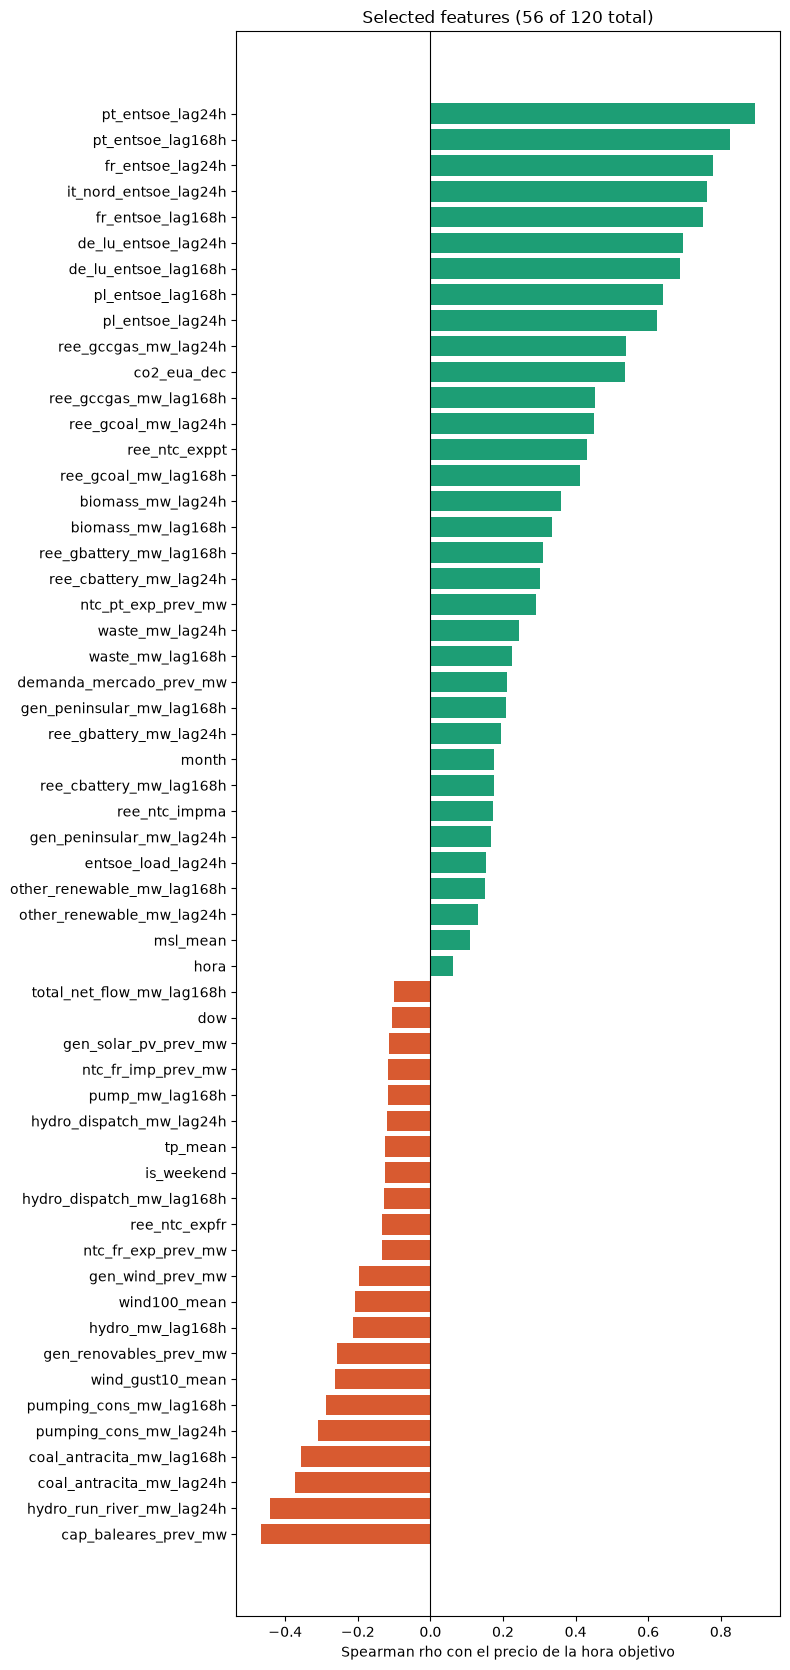

In [6]:
def plot_selected_features(result: dict, top_n: int = None):
    """
    Bar chart of Spearman rho (vs target) for the features `select_features_spearman`
    kept. Sign is preserved -- positive rho (feature rises with price) in one color,
    negative in another.
    """
    selected = result["selected"]
    corr = result["target_corr"][selected]

    if top_n is not None:
        corr = corr.reindex(corr.abs().sort_values(ascending=False).index[:top_n])

    corr = corr.sort_values()  # ascending, so strongest bars end up at the top when plotted

    colors = ["#1D9E75" if v > 0 else "#D85A30" for v in corr]

    fig, ax = plt.subplots(figsize=(8, max(4, len(corr) * 0.3)))
    ax.barh(corr.index, corr.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Spearman rho con el precio de la hora objetivo")
    ax.set_title(f"Selected features ({len(selected)} of {len(result['target_corr'])} total)")
    plt.tight_layout()
    plt.show()


plot_selected_features(result)                # all selected features
# plot_selected_features(result, top_n=25)    # just the strongest 25, if the full list is too tall

# Sequential Feature Selector

In [7]:
def select_features_sfs(
    X: pd.DataFrame,
    y: pd.Series,
    n_features_to_select: str | int = "auto",
    direction: str = "forward",
    n_splits: int = 5,
    scoring: str = "neg_mean_absolute_error",
    max_filas: int | None = 24 * 365,
) -> dict:
    """
    Wrapper de seleccion secuencial. Se ajusta SOLO sobre el split de train --
    la seleccion no debe ver filas de val/test (fuga de informacion).

    Usa TimeSeriesSplit en vez de KFold: al ser una serie temporal, la CV nunca
    debe barajar las horas (evita entrenar con "futuro" y validar con "pasado").

    n_features_to_select="auto" deja que sklearn pare cuando dejar de mejorar
    el score deja de compensar (usa el parametro `tol`, por defecto None -> mitad
    de las features de entrada). Puedes fijar un numero concreto en su lugar.

    max_filas: el dataset horario tiene ~24x mas filas que el diario, y SFS entrena
    O(n_features^2) x n_splits modelos -- con el train completo esto pasa de horas.
    Por defecto la seleccion se hace sobre las ultimas `max_filas` horas de train
    (1 año, suficiente para cubrir el ciclo estacional completo). Pon None para
    usar todo el train si tienes tiempo de computo de sobra.

    Devuelve:
      selected  -- lista final de features
      estimator -- el modelo usado para evaluar cada subconjunto (ya no esta fit,
                   es solo la referencia -- hay que reentrenarlo sobre selected)
    """
    if max_filas is not None and len(X) > max_filas:
        X, y = X.iloc[-max_filas:], y.iloc[-max_filas:]
        print(f"SFS ajustado sobre las ultimas {max_filas} horas de train ({X.index.min()} -> {X.index.max()})")

    estimator = RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
    )
    cv = TimeSeriesSplit(n_splits=n_splits)

    sfs = SequentialFeatureSelector(
        estimator,
        n_features_to_select=n_features_to_select,
        direction=direction,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
    )
    sfs.fit(X, y)

    selected = X.columns[sfs.get_support()].tolist()

    return {
        "selected": selected,
        "estimator": estimator,
        "sfs": sfs,
    }

In [8]:
result_sfs = select_features_sfs(X_train_sel, y_train, n_features_to_select="auto", direction="forward")
selected_sfs = result_sfs["selected"]

X_train_sfs = X_train_sel[selected_sfs]
X_val_sfs = X_val_sel[selected_sfs]


print(f"{len(selected_sfs)} de {X_train_sel.shape[1]} features conservadas (tras Spearman + SFS)")

SFS ajustado sobre las ultimas 8760 horas de train (2024-01-01 22:00:00+00:00 -> 2024-12-31 22:00:00+00:00)
28 de 56 features conservadas (tras Spearman + SFS)


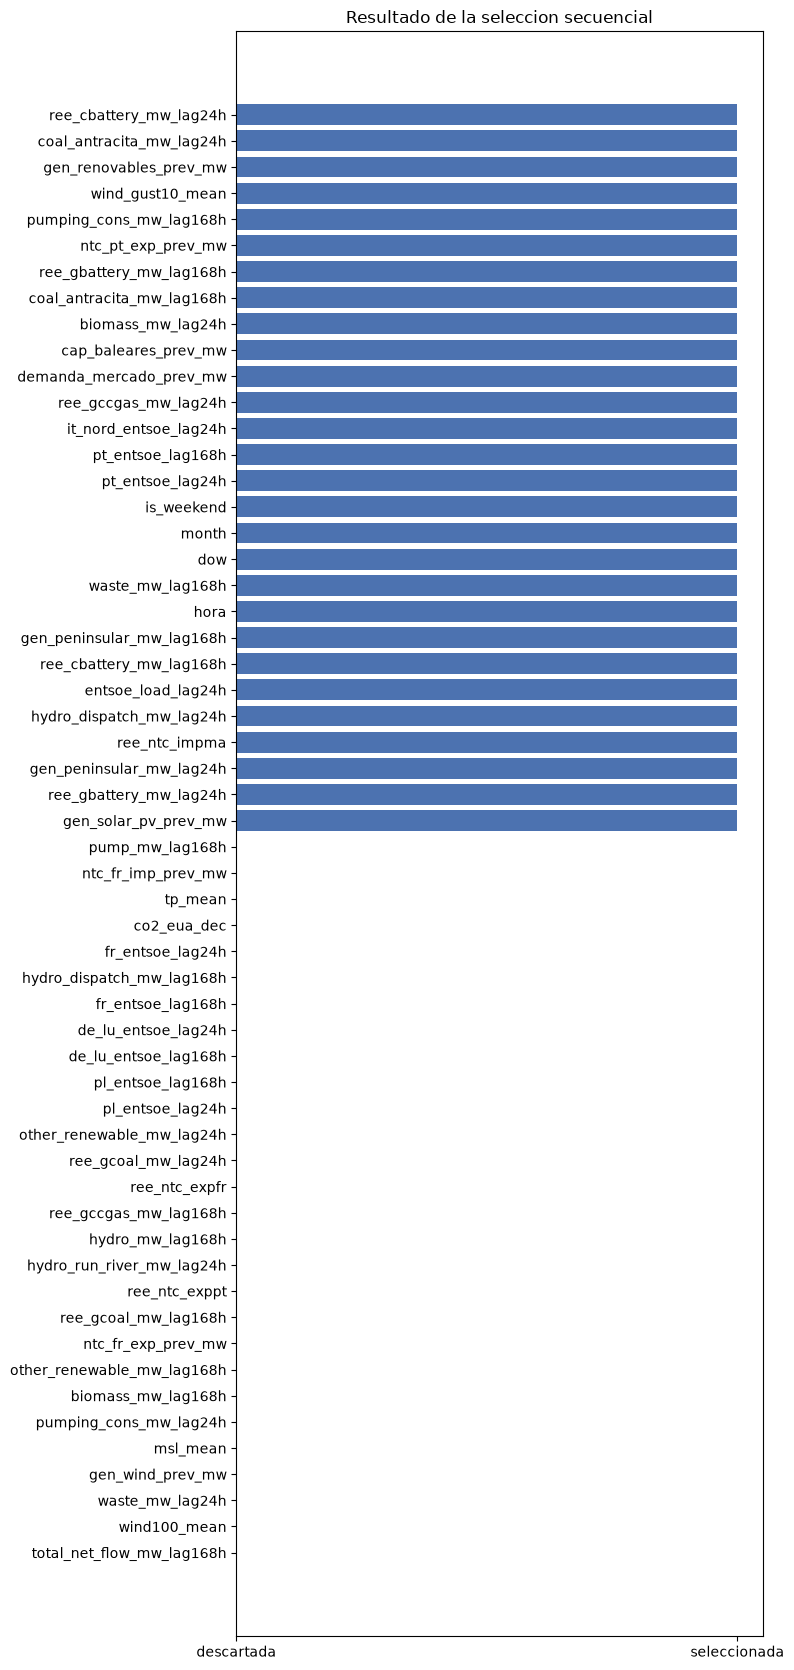

In [48]:
mask = X_train_sel.columns.isin(selected_sfs)
colors = np.where(mask, "#4C72B0", "#CCCCCC")
order = np.argsort(mask)  # descartadas arriba, seleccionadas abajo

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * X_train_sel.shape[1])))
ax.barh(X_train_sel.columns[order], mask[order].astype(int), color=colors[order])
ax.set_xticks([0, 1]); ax.set_xticklabels(["descartada", "seleccionada"])
ax.set_title("Resultado de la seleccion secuencial")
fig.tight_layout()
plt.show()

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def matriz_correlacion(X: pd.DataFrame, features: list = None, method: str = "spearman") -> pd.DataFrame:
    """Matriz de correlacion (por defecto Spearman) entre las features indicadas.
    Solo columnas numericas; las constantes se descartan porque rho no esta definido."""
    cols = features if features is not None else X.columns.tolist()
    X_num = X[cols].select_dtypes(include=[np.number])

    constantes = [c for c in X_num.columns if X_num[c].nunique(dropna=True) <= 1]
    if constantes:
        X_num = X_num.drop(columns=constantes)

    return X_num.corr(method=method)


def pares_mas_correlados(corr: pd.DataFrame, top_n: int = 15, umbral: float = None) -> pd.DataFrame:
    """Pares de features ordenados por |rho| descendente (triangulo superior, sin diagonal).
    Si pasas `umbral`, devuelve solo los pares que lo superan."""
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    pares = (
        corr.where(mask)
        .stack()
        .rename("rho")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    pares["abs_rho"] = pares["rho"].abs()
    pares = pares.sort_values("abs_rho", ascending=False)

    if umbral is not None:
        return pares[pares["abs_rho"] >= umbral].reset_index(drop=True)
    return pares.head(top_n).reset_index(drop=True)


def plot_corr_heatmap(corr: pd.DataFrame, titulo: str = "", etiquetas: bool = None):
    """Heatmap de la matriz de correlacion. Con muchas features las etiquetas
    se ocultan solas para que el grafico siga siendo legible."""
    n = len(corr)
    if etiquetas is None:
        etiquetas = n <= 40

    fig, ax = plt.subplots(figsize=(max(6, n * 0.25), max(5, n * 0.25)))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

    if etiquetas:
        ax.set_xticks(range(n), corr.columns, rotation=90, fontsize=7)
        ax.set_yticks(range(n), corr.index, fontsize=7)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    ax.set_title(f"{titulo}  ({n} features)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman rho")
    plt.tight_layout()
    plt.show()

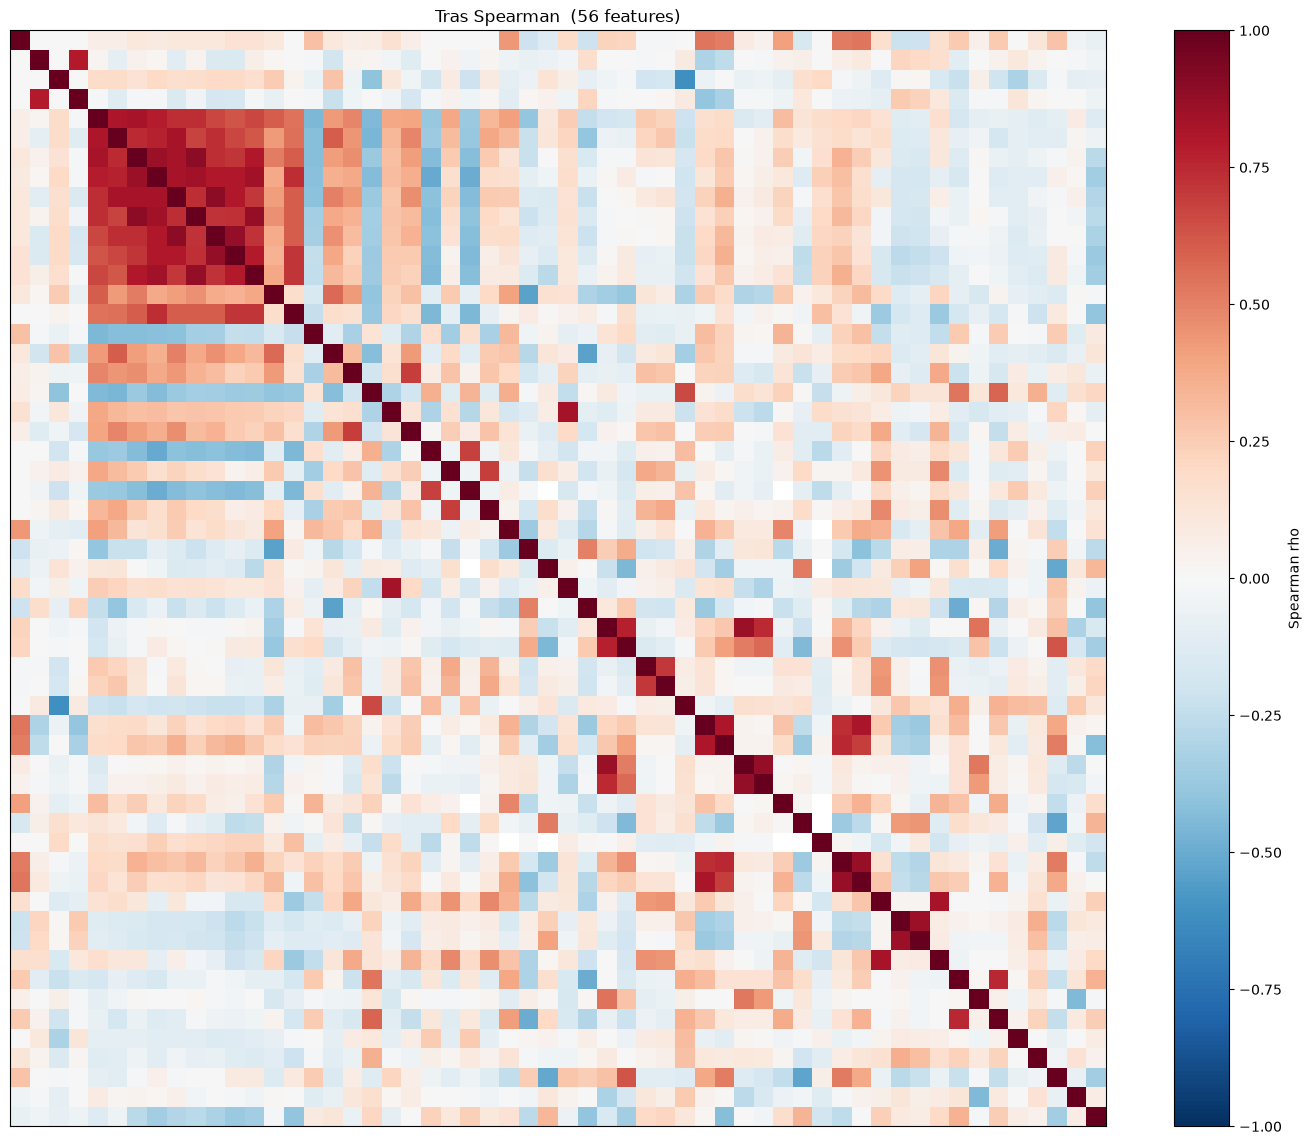

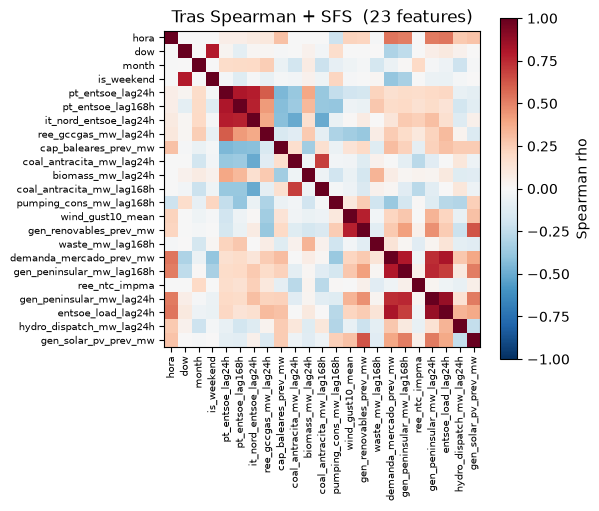

Pares mas correlados tras Spearman:
                  feature_a              feature_b       rho   abs_rho
0          fr_entsoe_lag24h    de_lu_entsoe_lag24h  0.892511  0.892511
1         fr_entsoe_lag168h   de_lu_entsoe_lag168h  0.892468  0.892468
2              wind100_mean       gen_wind_prev_mw  0.882434  0.882434
3      de_lu_entsoe_lag168h      pl_entsoe_lag168h  0.879463  0.879463
4       de_lu_entsoe_lag24h       pl_entsoe_lag24h  0.879441  0.879441
5  gen_peninsular_mw_lag24h     entsoe_load_lag24h  0.874667  0.874667
6          fr_entsoe_lag24h  it_nord_entsoe_lag24h  0.865204  0.865204
7          wind_gust10_mean           wind100_mean  0.862226  0.862226
8        ntc_fr_exp_prev_mw          ree_ntc_expfr  0.853677  0.853677
9     it_nord_entsoe_lag24h    de_lu_entsoe_lag24h  0.839296  0.839296

Pares mas correlados tras SFS:
                   feature_a                  feature_b       rho   abs_rho
0   gen_peninsular_mw_lag24h         entsoe_load_lag24h  0.874790  0.874790

In [ ]:
corr_spearman = matriz_correlacion(X_train_sel)   
corr_sfs      = matriz_correlacion(X_train_sfs)  

plot_corr_heatmap(corr_spearman, "Tras Spearman")
plot_corr_heatmap(corr_sfs, "Tras Spearman + SFS")

print("Pares mas correlados tras Spearman:")
print(pares_mas_correlados(corr_spearman, top_n=10))

print("\nPares mas correlados tras SFS:")
print(pares_mas_correlados(corr_sfs, top_n=10))

# colinealidad residual por encima del umbral que usaste en la etapa 2
for nombre, c in [("Spearman", corr_spearman), ("SFS", corr_sfs)]:
    altos = pares_mas_correlados(c, umbral=0.90)
    print(f"{nombre}: |rho| medio = {c.where(np.triu(np.ones(c.shape, bool), 1)).stack().abs().mean():.3f}, "
          f"pares con |rho| >= 0.90: {len(altos)}")

# tratamiento de datos

In [12]:
## rellena los huecos cortos usando interpolate
## OJO: ahora la rejilla es HORARIA, no diaria -- freq='h' y `limit` se cuenta en horas.
## limit=6 -> se rellenan huecos de hasta 6 horas; un hueco mas largo se deja como NaN
## a proposito, para que se vea (era un dia entero de datos perdidos, no un parpadeo).
def rellenar_gaps(df_or_series, limit=6, freq='h'):
    full_idx = pd.date_range(df_or_series.index.min(), df_or_series.index.max(), freq=freq)
    out = df_or_series.reindex(full_idx)
    out = out.interpolate(limit=limit)
    out.index.freq = freq
    return out

y_train = rellenar_gaps(y_train)
X_train_sfs = rellenar_gaps(X_train_sfs)


y_val = rellenar_gaps(y_val)
X_val_sfs = rellenar_gaps(X_val_sfs)


# tras interpolar, comprobar que no queden NaN (huecos mas largos que `limit` no se rellenan)
print("NaN restantes en X_train_sfs:", X_train_sfs.isna().sum().sum())
print("NaN restantes en y_train:", y_train.isna().sum())

NaN restantes en X_train_sfs: 182567
NaN restantes en y_train: 0


In [13]:
## Revisamos la correlacion de las columnas con muchos missing
missing_pct = X_train_sfs.isna().mean().sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 0.15]

# cruzar con su fuerza de correlacion con el target
print(pd.DataFrame({
    "missing_pct": high_missing,
    "target_corr": result["target_corr"].reindex(high_missing.index)
}))

                         missing_pct  target_corr
ree_cbattery_mw_lag168h     0.993204     0.175171
ree_gbattery_mw_lag168h     0.993204     0.310415
ree_cbattery_mw_lag24h      0.993135     0.301871
ree_gbattery_mw_lag24h      0.993135     0.193126
ntc_pt_exp_prev_mw          0.167514     0.290432


In [14]:
## Dropeamos las columnas con mucho missing Y correlacion debil con el target.
## En el dataset horario NO existen los sufijos _mean/_min/_max del dataset diario
## (ntc_fr_exp_prev_mw_mean ya no existe: ahora es ntc_fr_exp_prev_mw a secas), asi que
## la lista se calcula en vez de escribirse a mano -- si no, el drop peta con KeyError.

UMBRAL_CORR = 0.10
corr_abs = result["target_corr"].abs()

cols_a_dropear = [c for c in high_missing.index if corr_abs.get(c, 0) > UMBRAL_CORR]
cols_a_dropear = [c for c in cols_a_dropear if c in X_train_sfs.columns]
print("se dropean:", cols_a_dropear)

X_train_sfs = X_train_sfs.drop(columns=cols_a_dropear)
X_val_sfs = X_val_sfs.drop(columns=cols_a_dropear)

se dropean: ['ree_cbattery_mw_lag168h', 'ree_gbattery_mw_lag168h', 'ree_cbattery_mw_lag24h', 'ree_gbattery_mw_lag24h', 'ntc_pt_exp_prev_mw']


In [15]:
## Las que tienen mucho missing pero SI correlacionan se imputan en vez de dropearse
cols_imputar = [c for c in high_missing.index if c in X_train_sfs.columns]

# diagnostico: cuantas horas seguidas faltan al principio y al final de cada split
def _cola_nan(s):
    return int(s.isna()[::-1].cumprod().sum())

def _cabeza_nan(s):
    return int(s.isna().cumprod().sum())

for col in cols_imputar:
    print(f"{col}: train {_cabeza_nan(X_train_sfs[col])}h al inicio / {_cola_nan(X_train_sfs[col])}h al final, "
          f"val {_cabeza_nan(X_val_sfs[col])}h / {_cola_nan(X_val_sfs[col])}h")

# bfill cubre el bloque inicial, ffill el final (arrastra el ultimo valor conocido:
# no mira al futuro, asi que no hay fuga). limit=24 evita congelar un valor durante meses.
for col in cols_imputar:
    X_train_sfs[col] = X_train_sfs[col].bfill().ffill()  # se elimino limit = 24 de ffill
    X_val_sfs[col] = X_val_sfs[col].bfill().ffill()   # se elimino limit = 24 de ffill
print("\nImputado con bfill + ffill:", cols_imputar)

# verificacion final
print("NaN restantes en train:", X_train_sfs[cols_imputar].isna().sum().to_dict())
print("NaN restantes en val:", X_val_sfs[cols_imputar].isna().sum().to_dict())


Imputado con bfill + ffill: []
NaN restantes en train: {}
NaN restantes en val: {}


In [16]:
## interpolate no puede rellenar los iniciales, entonces los rellenamos usando bfill
## (limit=24 horas = el equivalente horario del limit=7 dias que usabas en el diario)
cols_con_missing = X_train_sfs.columns[X_train_sfs.isna().any()].tolist()
print(cols_con_missing)

for col in cols_con_missing:
    X_train_sfs[col] = X_train_sfs[col].bfill().ffill()  # se elimino limit = 24 de ffill
    X_val_sfs[col] = X_val_sfs[col].bfill().ffill()  # se elimino limit = 24 de ffill

print("NaN restantes en train:", X_train_sfs.isna().sum().sum())
print("NaN restantes en test:", X_val_sfs.isna().sum().sum())

['pt_entsoe_lag24h', 'pt_entsoe_lag168h', 'it_nord_entsoe_lag24h', 'ree_gccgas_mw_lag24h', 'coal_antracita_mw_lag24h', 'biomass_mw_lag24h', 'coal_antracita_mw_lag168h', 'pumping_cons_mw_lag168h', 'waste_mw_lag168h', 'gen_peninsular_mw_lag168h', 'gen_peninsular_mw_lag24h', 'entsoe_load_lag24h', 'hydro_dispatch_mw_lag24h']
NaN restantes en train: 0
NaN restantes en test: 0


In [17]:
# La receta de tratamiento, empaquetada. Se aplica aqui a validation, y es EXACTAMENTE
# la misma funcion que se usara sobre el test el dia que se abra -- asi no hay forma de
# que el test reciba un preprocesado distinto (ni mejor ni peor) que el de validation.
#
# Todo lo que necesita (selected_sfs, cols_a_dropear, cols_imputar, cols_con_missing)
# se calculo SOLO con train.
def aplicar_tratamiento(X_raw: pd.DataFrame) -> pd.DataFrame:
    X = X_raw[selected_sfs].copy()
    X = rellenar_gaps(X)
    X = X.drop(columns=[c for c in cols_a_dropear if c in X.columns])
    for col in cols_imputar:
        if col in X.columns:
            X[col] = X[col].bfill().ffill() # se elimino limit = 24 de ffill
    for col in cols_con_missing:
        if col in X.columns:
            X[col] = X[col].bfill().ffill() # se elimino limit = 24 de ffill
    return X[X_train_sfs.columns]

# Verificar que val ya coincide en columnas y no tiene NaN
print("Columnas iguales a train:", list(X_val_sfs.columns) == list(X_train_sfs.columns))
print("NaN restantes en val:", X_val_sfs.isna().sum().sum())

Columnas iguales a train: True
NaN restantes en val: 0


In [18]:
print("NaN totales en X_train_sfs:", X_train_sfs.isna().sum().sum())
print("NaN totales en X_test_sfs:", X_val_sfs.isna().sum().sum())
print("Inf totales en X_train_sfs:", np.isinf(X_train_sfs.select_dtypes(include=[np.number])).sum().sum())

NaN totales en X_train_sfs: 0
NaN totales en X_test_sfs: 0
Inf totales en X_train_sfs: 0


In [19]:
## Igualamos todos los indices.
## El dataset horario viene con tz UTC. statsmodels/pmdarima quieren un DatetimeIndex
## regular con freq: sobre UTC (sin cambios de hora) quitar la tz NO altera el espaciado,
## y ademas evita los warnings de "no supported index". Si conviertieramos a Europe/Madrid
## antes de quitar la tz, los dias de DST tendrian 23 o 25 horas y el freq='h' se romperia.
def normalizar_indice(obj):
    obj = obj.copy()
    idx = pd.DatetimeIndex(obj.index)
    if idx.tz is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    obj.index = idx
    return obj

y_train, y_val = normalizar_indice(y_train), normalizar_indice(y_val)
X_train_sfs = normalizar_indice(X_train_sfs)
X_val_sfs = normalizar_indice(X_val_sfs)


for nombre, s in [("y_train", y_train), ("y_val", y_val)]:
    print(nombre, s.index.dtype, len(s))

y_train datetime64[us] 43847
y_val datetime64[us] 8760


In [20]:
y_train = y_train.sort_index()
X_train_sfs = X_train_sfs.sort_index()

y_train = rellenar_gaps(y_train)
X_train_sfs = rellenar_gaps(X_train_sfs)  # ya deja el freq puesto, como viste antes


print("freq y_train:", y_train.index.freq)
print("freq X_train_sfs:", X_train_sfs.index.freq)
print("NaN tras rellenar_gaps:", y_train.isna().sum(), X_train_sfs.isna().sum().sum())
print("Longitud:", len(y_train), len(X_train_sfs))

freq y_train: <Hour>
freq X_train_sfs: <Hour>
NaN tras rellenar_gaps: 0 0
Longitud: 43847 43847


# SARIMA


In [22]:
# 1. Buscar orden propio para el modelo sin exogenas
#
# CAMBIO CLAVE respecto al dataset diario: m=24, no m=7. En horario el ciclo dominante
# es el del dia (24 horas); el semanal (m=168) es inviable en SARIMA -- si lo quieres
# capturar, dejalo en manos de las features `dow` / `is_weekend` y de los lags 168h.
#
# auto_arima con m=24 sobre decenas de miles de horas es MUY lento (cada fit estima
# una matriz de estado de tamaño ~m). Se busca el orden sobre la ventana MAS RECIENTE
# DE TRAIN (termina el 31-dic-2024) y despues se ajusta con todo train.
VENTANA_ORDEN = 24 * 120  # 120 dias

auto_sin_exog = pm.auto_arima(
    y_train.iloc[-VENTANA_ORDEN:],
    seasonal=True, m=24,
    d=None, D=None,
    max_p=3, max_q=3, max_P=1, max_Q=1,
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True,
)
order_sin_exog = auto_sin_exog.order
seasonal_order_sin_exog = auto_sin_exog.seasonal_order
print(order_sin_exog, seasonal_order_sin_exog)

# Si aun asi tarda demasiado, salta la busqueda y fija un orden razonable de referencia
# para precio horario, dejando constancia en la memoria de que se fijo a mano:
# order_sin_exog, seasonal_order_sin_exog = (2, 0, 1), (1, 1, 1, 24)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=10.98 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=23523.987, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=21872.068, Time=1.72 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=22264.293, Time=1.73 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=23521.988, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=22704.458, Time=0.07 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=3.66 sec
 ARIMA(1,1,0)(0,0,1)[24] intercept   : AIC=22253.151, Time=1.50 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=21986.439, Time=1.04 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=21860.422, Time=2.72 sec
 ARIMA(2,1,0)(0,0,0)[24] intercept   : AIC=22625.995, Time=0.12 sec
 ARIMA(2,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=5.04 sec
 ARIMA(2,1,0)(0,0,1)[24] intercept   : AIC=22227.188, Time=2.23 sec
 ARIMA(3,1,0)(1,0,0)[24] intercept   : AIC=21855.901, Time=3.54 sec
 ARIMA(3,1,0)(0,0,0)[2

In [23]:
# 2. Ajustar sobre train (hasta 31-dic-2024)
sarima_fit = SARIMAX(
    y_train,
    order=order_sin_exog,
    seasonal_order=seasonal_order_sin_exog,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

In [ ]:
# 3. Walk-forward sobre VALIDATION (2025), sin exog.
# Un año de horas son ~8760 pasos: `refit=False` mantiene los parametros fijos y solo
# actualiza el estado, que es lo unico que hace esto viable.
predictions = []
current_fit = sarima_fit
for t in range(len(y_val)):
    pred = current_fit.forecast(steps=1)
    predictions.append(pred.iloc[0])
    current_fit = current_fit.append([y_val.iloc[t]], refit=False)
    if (t + 1) % 500 == 0:
        print(f"  {t + 1}/{len(y_val)} horas")

predictions = pd.Series(predictions, index=y_val.index)

In [29]:
# 3. Prediccion directa sobre validation (2025), sin walk-forward.
# El modelo ya ajustado con train predice las ~8760 horas de un tiron, sin ver
# ningun valor real de 2025 por el camino.
predictions = sarima_fit.forecast(steps=len(y_val))
predictions = pd.Series(np.asarray(predictions), index=y_val.index)

print(predictions.head())

2024-12-31 23:00:00    138.937484
2025-01-01 00:00:00    135.898931
2025-01-01 01:00:00    135.110701
2025-01-01 02:00:00    133.639275
2025-01-01 03:00:00    129.851133
dtype: float64


In [25]:
# Prediccion por bloques de 24h: cada dia se predice entero, y despues se le da al
# modelo el dia observado antes de pasar al siguiente. 365 iteraciones en vez de 8760.
bloques = []
current_fit = sarima_fit
for ini in range(0, len(y_val), 24):
    bloque = y_val.iloc[ini:ini + 24]
    bloques.append(pd.Series(np.asarray(current_fit.forecast(steps=len(bloque))), index=bloque.index))
    current_fit = current_fit.append(bloque, refit=False)

predictions = pd.concat(bloques)
print(len(predictions), "horas predichas")

8760 horas predichas


In [26]:
mae = mean_absolute_error(y_val, predictions)
rmse = np.sqrt(mean_squared_error(y_val, predictions))
print(f"SARIMA (validation 2025): MAE: {mae:.2f} €/MWh  RMSE: {rmse:.2f} €/MWh")

SARIMA (validation 2025): MAE: 22.68 €/MWh  RMSE: 31.21 €/MWh


# SARIMAX

In [30]:
# 1. Buscar orden (p,d,q)(P,D,Q,m) con las exogenas incluidas
# m=24 (ciclo diario) y misma ventana reciente que en el SARIMA sin exogenas.
# `X=` en vez de `exogenous=`: el segundo esta deprecado en pmdarima >= 1.8.
auto = pm.auto_arima(
    y_train.iloc[-VENTANA_ORDEN:],
    X=X_train_sfs.iloc[-VENTANA_ORDEN:],   # variables seleccionadas por Spearman + SFS
    seasonal=True, m=24,
    d=None, D=None,
    max_p=3, max_q=3, max_P=1, max_Q=1,
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True,
)
order = auto.order
seasonal_order = auto.seasonal_order
print(order, seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=20542.150, Time=46.36 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=24147.083, Time=1.64 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=20583.963, Time=35.64 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=23220.309, Time=24.76 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=44207.045, Time=1.36 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=20555.100, Time=46.21 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=20554.717, Time=38.24 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=20523.330, Time=4.76 sec
 ARIMA(1,0,2)(0,0,0)[24] intercept   : AIC=20495.526, Time=7.72 sec
 ARIMA(1,0,2)(1,0,0)[24] intercept   : AIC=20552.013, Time=37.69 sec
 ARIMA(1,0,2)(0,0,1)[24] intercept   : AIC=20555.318, Time=47.00 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=20544.090, Time=48.78 sec
 ARIMA(0,0,2)(0,0,0)[24] intercept   : AIC=21889.676, Time=6.18 sec
 ARIMA(1,0,1)(0,0,0)[24] intercept   : AIC=20506.599, Time=7.13 s

c:\Users\Powan\Desktop\Maestria\TFM\tfm-env\tfm_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
c:\Users\Powan\Desktop\Maestria\TFM\tfm-env\tfm_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(2,0,3)(0,0,0)[24] intercept   : AIC=27727.570, Time=3.22 sec
 ARIMA(1,0,2)(0,0,0)[24]             : AIC=20474.507, Time=7.61 sec
 ARIMA(1,0,2)(1,0,0)[24]             : AIC=20553.580, Time=38.67 sec
 ARIMA(1,0,2)(0,0,1)[24]             : AIC=20555.344, Time=44.30 sec
 ARIMA(1,0,2)(1,0,1)[24]             : AIC=20540.674, Time=43.67 sec
 ARIMA(0,0,2)(0,0,0)[24]             : AIC=21888.045, Time=4.39 sec
 ARIMA(1,0,1)(0,0,0)[24]             : AIC=20528.941, Time=3.99 sec
 ARIMA(2,0,2)(0,0,0)[24]             : AIC=20521.493, Time=4.68 sec
 ARIMA(1,0,3)(0,0,0)[24]             : AIC=20496.839, Time=8.88 sec
 ARIMA(0,0,1)(0,0,0)[24]             : AIC=23228.259, Time=7.57 sec
 ARIMA(0,0,3)(0,0,0)[24]             : AIC=21467.550, Time=15.88 sec
 ARIMA(2,0,1)(0,0,0)[24]             : AIC=20516.540, Time=7.66 sec
 ARIMA(2,0,3)(0,0,0)[24]             : AIC=27725.708, Time=2.66 sec

Best model:  ARIMA(1,0,2)(0,0,0)[24]          
Total fit time: 576.643 seconds
(1, 0, 2) (0, 0, 0, 24)


In [31]:
# Reajustar SARIMAX sobre el historial completo (train+val), con el order/seasonal_order
# ya encontrado antes con auto_arima sobre train
sarimax_fit = SARIMAX(
    y_train,
    exog=X_train_sfs,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

c:\Users\Powan\Desktop\Maestria\TFM\tfm-env\tfm_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## walkfoward

In [ ]:
# Ahora si, el walk-forward sobre test parte de un indice que continua sin huecos
predictions_sarimax = []
current_fit = sarimax_fit
for t in range(len(y_val)):
    exog_t = X_val_sfs.iloc[[t]]
    pred = current_fit.forecast(steps=1, exog=exog_t)
    predictions_sarimax.append(pred.iloc[0])
    current_fit = current_fit.append([y_val.iloc[t]], exog=exog_t, refit=False)
    if (t + 1) % 500 == 0:
        print(f"  {t + 1}/{len(y_val)} horas")

predictions_sarimax = pd.Series(predictions_sarimax, index=y_val.index)

## basico

In [32]:
predictions_sarimax = sarimax_fit.forecast(steps=len(y_val), exog=X_val_sfs)
predictions_sarimax = pd.Series(np.asarray(predictions_sarimax), index=y_val.index)

print(predictions_sarimax.head())

2024-12-31 23:00:00    138.206805
2025-01-01 00:00:00    135.922221
2025-01-01 01:00:00    131.114203
2025-01-01 02:00:00    125.970334
2025-01-01 03:00:00    119.233867
dtype: float64


In [ ]:
# 4. Metricas, comparables con el resto de modelos ML y con el SARIMA sin exogenas

mae = mean_absolute_error(y_val, predictions_sarimax)
rmse = np.sqrt(mean_squared_error(y_val, predictions_sarimax))
print(f"SARIMAX + exog: MAE: {mae:.2f} €/MWh  RMSE: {rmse:.2f} €/MWh")

# regresion lineal


## Rigde

In [33]:

X_train_sfs = pd.DataFrame(X_train_sfs)
X_val_sfs = pd.DataFrame(X_val_sfs)

In [34]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sfs), index=X_train_sfs.index, columns=X_train_sfs.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_sfs), index=X_val_sfs.index, columns=X_val_sfs.columns)


In [35]:
alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 200, 500]

resultados_ridge = []
for alpha in alphas:
    modelo = Ridge(alpha=alpha)
    modelo.fit(X_train_scaled, y_train)
    pred_val = modelo.predict(X_val_scaled)
    resultados_ridge.append({"alpha": alpha, "MAE_val": mean_absolute_error(y_val, pred_val)})

resultados_ridge = pd.DataFrame(resultados_ridge).sort_values("MAE_val")
print(resultados_ridge)

best_alpha_ridge = resultados_ridge.iloc[0]["alpha"]
print(f"\nMejor alpha (Ridge): {best_alpha_ridge}")

     alpha    MAE_val
9  500.000  15.073402
8  200.000  15.078233
7  100.000  15.090298
6   50.000  15.098889
5   10.000  15.107307
4    5.000  15.108431
3    1.000  15.109337
2    0.100  15.109542
1    0.010  15.109563
0    0.001  15.109565

Mejor alpha (Ridge): 500.0


In [36]:
# Ridge final de esta fase: ajustado con train, evaluado sobre validation (2025)
ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_train_scaled, y_train)
ridge_pred = pd.Series(ridge_final.predict(X_val_scaled), index=y_val.index)

In [37]:
metricas = calcular_metricas(y_val, predictions_dict)
print(metricas)

NameError: name 'calcular_metricas' is not defined

## ElasticNet

In [38]:
from sklearn.linear_model import ElasticNet
import itertools

alphas_en = [0.001, 0.01, 0.1, 1, 5, 10]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]  # 1.0 = Lasso puro

resultados_en = []
for alpha, l1_ratio in itertools.product(alphas_en, l1_ratios):
    modelo = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
    modelo.fit(X_train_scaled, y_train)
    pred_val = modelo.predict(X_val_scaled)
    resultados_en.append({
        "alpha": alpha, "l1_ratio": l1_ratio,
        "MAE_val": mean_absolute_error(y_val, pred_val)
    })

resultados_en = pd.DataFrame(resultados_en).sort_values("MAE_val")
print(resultados_en.head(10))

best_alpha_en = resultados_en.iloc[0]["alpha"]
best_l1_ratio_en = resultados_en.iloc[0]["l1_ratio"]
print(f"\nMejor combinacion (ElasticNet): alpha={best_alpha_en}, l1_ratio={best_l1_ratio_en}")

    alpha  l1_ratio    MAE_val
17  0.100       1.0  14.999259
16  0.100       0.9  15.059292
7   0.010       0.3  15.068397
6   0.010       0.1  15.069218
8   0.010       0.5  15.071205
9   0.010       0.7  15.077381
10  0.010       0.9  15.087604
11  0.010       1.0  15.094889
0   0.001       0.1  15.100833
1   0.001       0.3  15.102372

Mejor combinacion (ElasticNet): alpha=0.1, l1_ratio=1.0


In [39]:
# ElasticNet final
en_final = ElasticNet(alpha=best_alpha_en, l1_ratio=best_l1_ratio_en, max_iter=10000)
en_final.fit(X_train_scaled, y_train)
elasticnet_pred = pd.Series(en_final.predict(X_val_scaled), index=y_val.index)

In [ ]:
metricas = calcular_metricas(y_val, predictions_dict)
print(metricas)

# graficos y tablas

In [40]:
# Baseline naive HORARIO: el precio de la MISMA hora del dia anterior (t-24), no t-1.
# El t-1 del dataset diario era "el precio de ayer"; su equivalente aqui es 24 posiciones
# atras. Se toma de train+val concatenados para que las 24 primeras horas de validation
# tampoco necesiten bfill (que ademas miraria hacia el futuro).
serie_completa = pd.concat([y_train, y_val]).sort_index()
naive_pred = serie_completa.shift(24).reindex(y_val.index)

print("NaN en naive_pred:", naive_pred.isna().sum())

NaN en naive_pred: 0


In [46]:
predictions_dict = {
    "Naive (t-24)": naive_pred,
    "SARIMA (sin exog)": predictions,
    "SARIMAX (+exog)": predictions_sarimax,
    "Rigde": ridge_pred,
    "Elastic": elasticnet_pred,

}

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calcular_metricas(y_true, predictions_dict, nombre_naive="Naive (t-24)"):
    mae_naive = mean_absolute_error(y_true, predictions_dict[nombre_naive])

    filas = []
    for nombre, pred in predictions_dict.items():
        pred_alineado = pred.reindex(y_true.index)
        mae = mean_absolute_error(y_true, pred_alineado)
        rmse = np.sqrt(mean_squared_error(y_true, pred_alineado))
        filas.append({
            "modelo": nombre,
            "MAE": mae,
            "RMSE": rmse,
            "rMAE": mae / mae_naive,
        })
    return pd.DataFrame(filas).set_index("modelo").sort_values("MAE")

In [43]:
def plot_predicciones_vs_real(y_true, predictions_dict, zoom_horas=None):
    """
    Un panel por modelo, con el precio real superpuesto en cada uno.
    zoom_horas: si se indica (ej. 24*14), solo muestra las ultimas N horas del test
                -- imprescindible en horario: el test completo son miles de puntos
                y el grafico queda ilegible.
    """
    y_plot = y_true
    preds_plot = predictions_dict
    if zoom_horas is not None:
        y_plot = y_true.iloc[-zoom_horas:]
        preds_plot = {name: pred.reindex(y_plot.index) for name, pred in predictions_dict.items()}

    n = len(preds_plot)
    fig, axes = plt.subplots(n, 1, figsize=(11, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (nombre, pred) in zip(axes, preds_plot.items()):
        ax.plot(y_plot.index, y_plot.values, label="Real", color="#333333", linewidth=1.5)
        ax.plot(pred.index, pred.values, label=nombre, color="#D85A30", linewidth=1.2, alpha=0.85)
        ax.set_title(nombre)
        ax.set_ylabel("€/MWh")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)

    plt.xlabel("Hora")
    plt.tight_layout()
    plt.show()

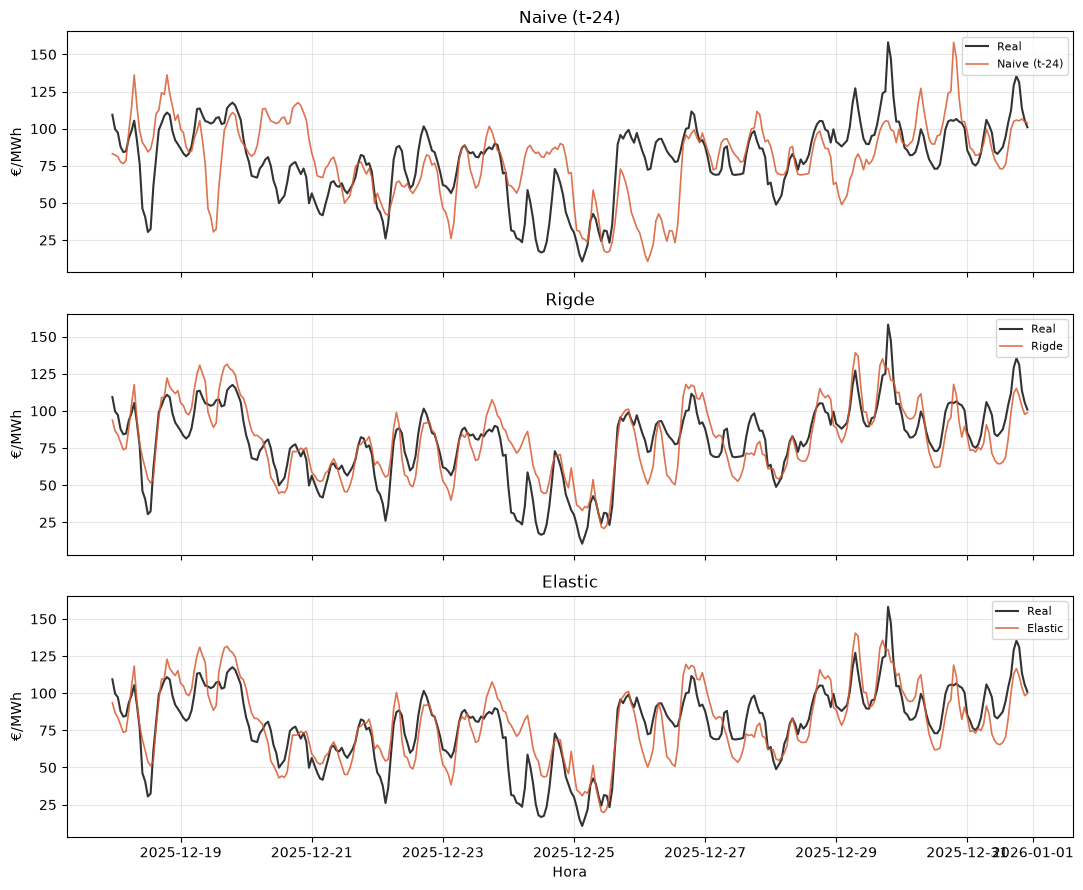

In [44]:
# periodo completo de test
## plot_predicciones_vs_real(y_test, predictions_dict)

# zoom a las ultimas 2 semanas, para ver el detalle del perfil intradiario
plot_predicciones_vs_real(y_val, predictions_dict, zoom_horas=24 * 14)

In [ ]:
# periodo completo de test
plot_predicciones_vs_real(y_val, predictions_dict)

In [47]:
def tabla_predicciones(y_true, predictions_dict):
    tabla = pd.DataFrame({"Real": y_true})
    for nombre, pred in predictions_dict.items():
        pred_alineado = pred.reindex(y_true.index)
        tabla[nombre] = pred_alineado
        tabla[f"MAE {nombre}"] = (y_true - pred_alineado).abs()  # == MAE de esa hora, n=1
    return tabla.round(2)

tabla = tabla_predicciones(y_val, predictions_dict)
tabla

,Real,Naive (t-24),MAE Naive (t-24),SARIMA (sin exog),MAE SARIMA (sin exog),SARIMAX (+exog),MAE SARIMAX (+exog),Rigde,MAE Rigde,Elastic,MAE Elastic
2024-12-31 23:00:00,134.49,145.00,10.51,138.94,4.45,138.21,3.72,130.26,4.23,130.56,3.93
2025-01-01 00:00:00,131.59,139.03,7.44,135.90,4.31,135.92,4.33,131.66,0.07,132.01,0.42
2025-01-01 01:00:00,131.49,137.48,5.99,135.11,3.62,131.11,0.38,127.98,3.51,128.30,3.19
2025-01-01 02:00:00,131.42,134.66,3.24,133.64,2.22,125.97,5.45,124.05,7.37,124.30,7.12
2025-01-01 03:00:00,120.49,127.37,6.88,129.85,9.36,119.23,1.26,117.25,3.24,117.27,3.22
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:00:00,135.43,105.77,29.66,132.52,2.91,137.86,2.43,115.18,20.25,116.58,18.85
2025-12-31 19:00:00,131.12,105.27,25.85,132.52,1.40,133.17,2.05,110.13,20.99,111.32,19.80
2025-12-31 20:00:00,113.66,106.52,7.14,132.52,18.86,124.50,10.84,103.04,10.62,103.90,9.76
2025-12-31 21:00:00,105.83,104.75,1.08,132.52,26.69,115.67,9.84,97.73,8.10,98.33,7.50
